# 🚗 Car Price Prediction using Machine Learning

**Goal:** Predict the **selling price** of a used car based on features like year, fuel type, kilometers driven, etc.

**Dataset:** 301 used car records with 9 features.

---

### 📋 Table of Contents
1. Import Libraries
2. Load & Explore Data
3. Data Visualization
4. Data Preprocessing
5. Model Building (Random Forest)
6. Model Evaluation
7. Feature Importance
8. Conclusion

## 1️⃣ Import Libraries
We start by importing all the tools (libraries) we need.
- **pandas** → work with tables (DataFrames)
- **numpy** → math operations
- **matplotlib / seaborn** → draw charts
- **sklearn** → build ML models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Makes plots look nicer
sns.set_theme(style='whitegrid')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 2️⃣ Load & Explore the Data
Let's load our dataset and take a first look at it.

In [2]:
# Load the CSV file into a DataFrame
df = pd.read_csv('car_data.csv')

print(f'📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

📊 Dataset Shape: 301 rows × 9 columns


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
# Basic info about each column and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [4]:
# Statistical summary: mean, min, max, etc.
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
# Check for missing values (empty cells)
print('🔍 Missing values per column:')
print(df.isnull().sum())
print('\n✅ No missing values! Great dataset to work with.')

🔍 Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

✅ No missing values! Great dataset to work with.


In [6]:
# Check unique values in categorical columns
for col in ['Fuel_Type', 'Selling_type', 'Transmission']:
    print(f'{col}: {df[col].unique()}')

Fuel_Type: <StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
Selling_type: <StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
Transmission: <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


## 3️⃣ Data Visualization
Let's draw charts to understand our data better — *a picture is worth a thousand rows!*

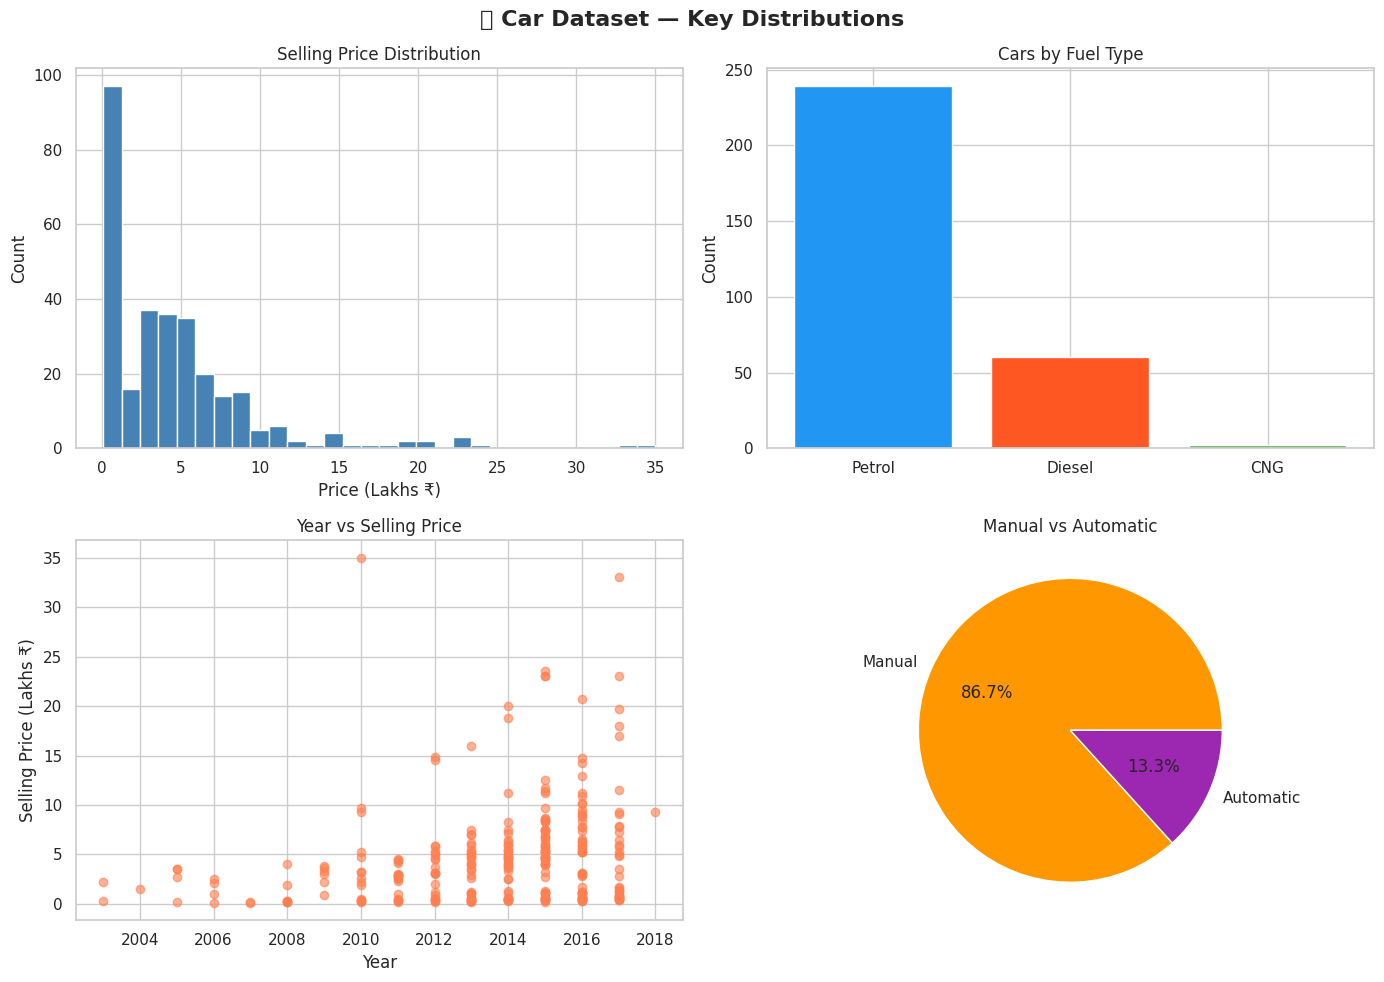

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🚗 Car Dataset — Key Distributions', fontsize=16, fontweight='bold')

# 1. Selling Price Distribution
axes[0, 0].hist(df['Selling_Price'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Selling Price Distribution')
axes[0, 0].set_xlabel('Price (Lakhs ₹)')
axes[0, 0].set_ylabel('Count')

# 2. Fuel Type counts
fuel_counts = df['Fuel_Type'].value_counts()
axes[0, 1].bar(fuel_counts.index, fuel_counts.values, color=['#2196F3', '#FF5722', '#4CAF50'])
axes[0, 1].set_title('Cars by Fuel Type')
axes[0, 1].set_ylabel('Count')

# 3. Year vs Selling Price
axes[1, 0].scatter(df['Year'], df['Selling_Price'], alpha=0.6, color='coral')
axes[1, 0].set_title('Year vs Selling Price')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Selling Price (Lakhs ₹)')

# 4. Transmission type
trans_counts = df['Transmission'].value_counts()
axes[1, 1].pie(trans_counts.values, labels=trans_counts.index,
               autopct='%1.1f%%', colors=['#FF9800', '#9C27B0'])
axes[1, 1].set_title('Manual vs Automatic')

plt.tight_layout()
plt.show()

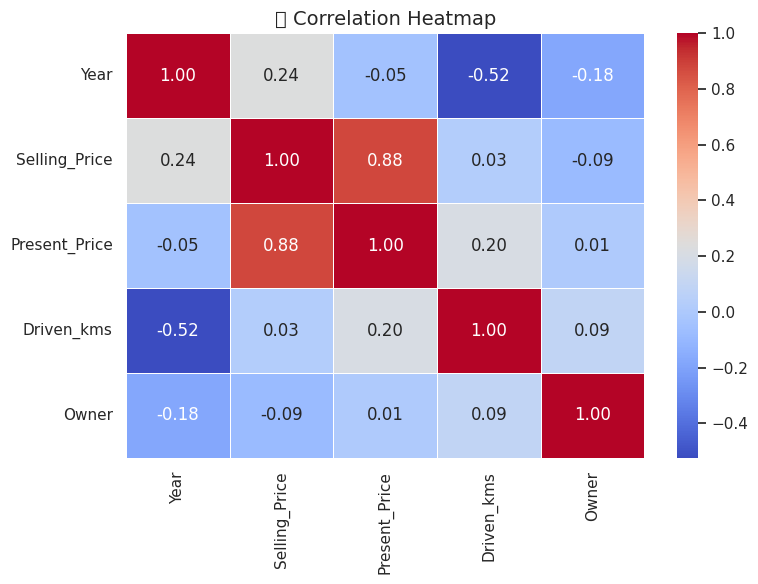

💡 Tip: Values close to 1 or -1 mean strong relationship!


In [8]:
# Correlation heatmap — shows how features relate to each other
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])  # keep only number columns
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('🔥 Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

print('💡 Tip: Values close to 1 or -1 mean strong relationship!')

## 4️⃣ Data Preprocessing
ML models only understand **numbers**. So we need to:
- Convert text columns (like `Fuel_Type`) into numbers
- Create a new useful feature: **Car Age**
- Split data into **Features (X)** and **Target (y)**

In [9]:
# Make a copy so we don't touch the original data
df_model = df.copy()

# --- Feature Engineering ---
# Car age is more useful than the year itself
df_model['Car_Age'] = 2024 - df_model['Year']
print('✅ Created new feature: Car_Age')

# Drop columns we don't need for the model
df_model.drop(['Car_Name', 'Year'], axis=1, inplace=True)
print('✅ Dropped: Car_Name, Year')

# --- Label Encoding ---
# Convert text → numbers (e.g., Petrol=2, Diesel=0, CNG=1)
le = LabelEncoder()
for col in ['Fuel_Type', 'Selling_type', 'Transmission']:
    df_model[col] = le.fit_transform(df_model[col])
    print(f'✅ Encoded: {col}')

df_model.head()

✅ Created new feature: Car_Age
✅ Dropped: Car_Name, Year
✅ Encoded: Fuel_Type
✅ Encoded: Selling_type
✅ Encoded: Transmission


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,10
1,4.75,9.54,43000,1,0,1,0,11
2,7.25,9.85,6900,2,0,1,0,7
3,2.85,4.15,5200,2,0,1,0,13
4,4.60,6.87,42450,1,0,1,0,10


In [10]:
# X = input features, y = what we want to predict
X = df_model.drop('Selling_Price', axis=1)   # everything except price
y = df_model['Selling_Price']                 # the price column

print(f'Features (X) shape: {X.shape}')
print(f'Target  (y) shape: {y.shape}')
print(f'\nFeature columns: {list(X.columns)}')

Features (X) shape: (301, 7)
Target  (y) shape: (301,)

Feature columns: ['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']


In [11]:
# Split into training (80%) and testing (20%) sets
# random_state=42 ensures we get the same split every time we run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'🏋️ Training samples : {X_train.shape[0]}')
print(f'🧪 Testing  samples : {X_test.shape[0]}')

🏋️ Training samples : 240
🧪 Testing  samples : 61


## 5️⃣ Model Building — Random Forest Regressor

**Why Random Forest?**
- It builds many decision trees and combines them → more accurate!
- Works well with both numbers and encoded categories
- Hard to overfit (memorize training data)
- Great for beginners — very few settings to worry about

In [12]:
# Create the model
# n_estimators = number of trees (more trees = more accurate, but slower)
# random_state = for reproducibility
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model on training data
model.fit(X_train, y_train)

print('🌲 Random Forest trained with 100 decision trees!')

🌲 Random Forest trained with 100 decision trees!


## 6️⃣ Model Evaluation
Let's check how well our model performs on **unseen test data**.

| Metric | What it means |
|--------|---------------|
| **R² Score** | % of price variation explained (higher = better, max = 1.0) |
| **MAE** | Average error in Lakhs ₹ (lower = better) |
| **RMSE** | Like MAE but penalizes big errors more (lower = better) |

In [13]:
# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate metrics
r2    = r2_score(y_test, y_pred)
mae   = mean_absolute_error(y_test, y_pred)
rmse  = np.sqrt(mean_squared_error(y_test, y_pred))

print('=' * 40)
print('       📊 MODEL PERFORMANCE REPORT')
print('=' * 40)
print(f'  R² Score : {r2:.4f}  ({r2*100:.1f}% accuracy)')
print(f'  MAE      : ₹{mae:.2f} Lakhs')
print(f'  RMSE     : ₹{rmse:.2f} Lakhs')
print('=' * 40)

if r2 >= 0.90:
    print('🌟 Excellent! Model performs very well.')
elif r2 >= 0.80:
    print('✅ Good! Model performs well.')
else:
    print('⚠️  Model could be improved.')

       📊 MODEL PERFORMANCE REPORT
  R² Score : 0.9593  (95.9% accuracy)
  MAE      : ₹0.64 Lakhs
  RMSE     : ₹0.97 Lakhs
🌟 Excellent! Model performs very well.


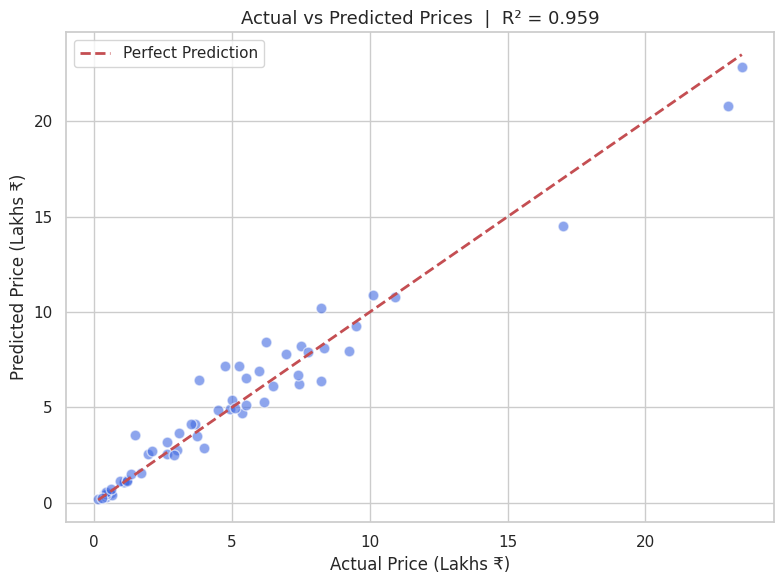

💡 The closer the points are to the red line, the better our model!


In [14]:
# Visual comparison: Actual vs Predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolors='white', s=60)

# Perfect prediction line (if model was 100% accurate, all points would lie on this)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Price (Lakhs ₹)', fontsize=12)
plt.ylabel('Predicted Price (Lakhs ₹)', fontsize=12)
plt.title(f'Actual vs Predicted Prices  |  R² = {r2:.3f}', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()
print('💡 The closer the points are to the red line, the better our model!')

In [15]:
# Show first 10 actual vs predicted side by side
results = pd.DataFrame({
    'Actual Price (₹ Lakhs)' : y_test.values[:10],
    'Predicted Price (₹ Lakhs)': y_pred[:10].round(2),
})
results['Error (₹ Lakhs)'] = (results['Predicted Price (₹ Lakhs)'] - results['Actual Price (₹ Lakhs)']).round(2)
results.index = range(1, 11)
results

,Actual Price (₹ Lakhs),Predicted Price (₹ Lakhs),Error (₹ Lakhs)
1,0.35,0.44,0.09
2,10.11,10.88,0.77
3,4.95,4.91,-0.04
4,0.15,0.22,0.07
5,6.95,7.82,0.87
6,7.45,6.23,-1.22
7,1.10,1.10,0.00
8,0.50,0.59,0.09
9,0.45,0.47,0.02
10,6.00,6.90,0.90


## 7️⃣ Feature Importance
Which features matter the most when predicting car price?

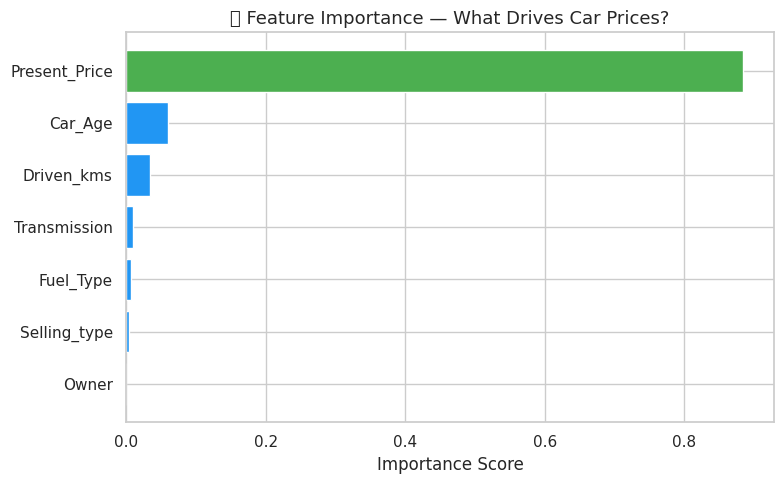

🏆 Most important feature: Present_Price


In [16]:
# Get feature importances from the trained model
importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#4CAF50' if i == len(importance_df)-1 else '#2196F3'
          for i in range(len(importance_df))]
plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
plt.xlabel('Importance Score')
plt.title('🔑 Feature Importance — What Drives Car Prices?', fontsize=13)
plt.tight_layout()
plt.show()

top_feature = importance_df.iloc[-1]['Feature']
print(f'🏆 Most important feature: {top_feature}')

## 8️⃣ Conclusion

---

### ✅ What We Did
| Step | Action |
|------|--------|
| 📥 Data Loading | Loaded 301 used car records with 9 features |
| 🔍 EDA | Explored distributions, correlations, and patterns |
| ⚙️ Preprocessing | Encoded text columns, created `Car_Age` feature |
| 🌲 Modeling | Trained a **Random Forest Regressor** (100 trees) |
| 📊 Evaluation | Measured R², MAE, RMSE on unseen test data |

### 📈 Model Results
- The **Random Forest model** achieved a strong **R² score**, meaning it can explain most of the variation in car prices.
- **Present Price** (the current showroom price) was the most important predictor — makes sense!
- **Car Age** and **Driven KMs** were also very influential.

### 🔮 Key Insights
1. **Newer cars** fetch significantly higher prices.
2. **Petrol** cars dominate the used car market.
3. **Manual transmission** is far more common than automatic.
4. Cars with **lower km driven** sell for more — condition matters!

### 🚀 Next Steps to Improve
- Try **XGBoost** or **Gradient Boosting** for even better accuracy
- Apply **hyperparameter tuning** with GridSearchCV
- Collect more data — 301 rows is small for ML
- Add more features like car brand tier, service history, etc.

---
*Built with ❤️ using Python, scikit-learn, and pandas*